# Traffic Route Optimization System
## Continous Evaluatoin - 1
This notebook contains the data preperation , preprocessing,
exploratory data analysis, feature engineering, and feature 
selection performed for the Traffic Route Optimization System.

The final objective of this stage is to prepare a clean, 
transformed, and analysed dataset ready for machine learning
model development.


## 1. Import Required Libraries

In [8]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import sklearn
print("All Libraries loaded Succefully")

All Libraries loaded Succefully


## 2. Problem Statement

In real-world transportation systems, selecting an efficient route can be affected by several factors such as traffic conditions, distance, travel-related conditions, and other environmental or road factors.

A route that is shortest in distance may not always be the quickest or most efficient route when traffic and other conditions are considered.

The objective of this project is to analyse relevant traffic and route data and develop a machine learning based approach that can assist in identifying an efficient route between a source and destination.


## 3. Project Objectives

1. Collect and understand a suitable dataset related to traffic and route conditions.

2. Clean and preprocess the dataset by handling duplicates, inconsistent data, missing values, and irrelevant information.

3. Perform exploratory data analysis and visualization to identify important patterns and relationships in the data.

4. Perform feature engineering and feature selection to identify relevant inputs for machine learning.

5. Prepare a clean and transformed dataset that is ready for subsequent machine learning model development.

## 4. Dataset Collection & Description

The dataset used for this project is the AetherGrid Smart Mobility Dataset. It contains mobility and traffic-related information for individual trips.

The dataset includes geographical information about the starting and ending locations of trips, trip distance, vehicle speed, traffic conditions, weather conditions, vehicle type, and temporal information.

The dataset is stored in CSV format and contains 50,000 records with 14 features. It will be used for data cleaning, exploratory data analysis, feature engineering, and preparation for subsequent machine learning model development.

In [9]:
import pandas as pd

# Path to the raw dataset
file_path = "../data/raw/AetherGrid_Mobility_Patterns_v2_Alpha9.csv"

# Load the dataset
df = pd.read_csv(file_path)

# Display the first five rows
df.head()

,user_id,trip_id,start_lat,start_lon,end_lat,end_lon,distance_km,speed_kmh,traffic,weather,vehicle_type,timestamp,day_of_week,is_weekend
0,U100,T9000,24.6970,67.4195,24.5436,67.7147,28.97,31.498106,Low,Clear,Bus,2025-01-24 12:20:00,4,0
1,U101,T9001,24.7596,67.0422,24.3896,67.3007,8.18,49.894966,Medium,Clear,Bus,2025-01-19 11:56:00,6,1
2,U102,T9002,24.1323,67.0737,23.7858,66.9700,13.45,34.706390,High,Clear,Bus,2025-01-28 10:51:00,1,0
3,U103,T9003,24.2530,67.8358,24.6431,68.0697,21.47,26.375888,High,Clear,Car,2025-01-29 08:53:00,2,0
4,U104,T9004,24.1442,66.7141,24.4542,66.3060,15.73,22.592173,High,Fog,Bike,2025-01-13 17:30:00,0,0


In [10]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

Dataset Shape: (50000, 14)

Column Names:
['user_id', 'trip_id', 'start_lat', 'start_lon', 'end_lat', 'end_lon', 'distance_km', 'speed_kmh', 'traffic', 'weather', 'vehicle_type', 'timestamp', 'day_of_week', 'is_weekend']

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   user_id       50000 non-null  str    
 1   trip_id       50000 non-null  str    
 2   start_lat     50000 non-null  float64
 3   start_lon     50000 non-null  float64
 4   end_lat       50000 non-null  float64
 5   end_lon       50000 non-null  float64
 6   distance_km   50000 non-null  float64
 7   speed_kmh     50000 non-null  float64
 8   traffic       50000 non-null  str    
 9   weather       50000 non-null  str    
 10  vehicle_type  50000 non-null  str    
 11  timestamp     50000 non-null  str    
 12  day_of_week   50000 non-null  int64  
 13  is_weeken

In [11]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
user_id,50000,50000,U100,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
trip_id,50000,50000,T9000,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
start_lat,50000.0,NaN,NaN,NaN,24.744345,0.435402,24.0,24.363575,24.7441,25.122325,25.5
start_lon,50000.0,NaN,NaN,NaN,67.253005,0.432677,66.5001,66.8785,67.2547,67.6273,68.0
end_lat,50000.0,NaN,NaN,NaN,24.743686,0.522188,23.5038,24.357275,24.7426,25.1288,25.9948
end_lon,50000.0,NaN,NaN,NaN,67.251135,0.520328,66.004,66.8654,67.2513,67.635025,68.4892
distance_km,50000.0,NaN,NaN,NaN,15.418266,8.339506,1.0,8.22,15.38,22.59,30.0
speed_kmh,50000.0,NaN,NaN,NaN,35.46503,13.788507,5.601448,24.845174,33.257728,44.924889,74.30668
traffic,50000,3,Low,18725,NaN,NaN,NaN,NaN,NaN,NaN,NaN
weather,50000,3,Clear,35010,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 5. Data Cleaning

Data cleaning is performed to identify and handle duplicate records, incorrect or inconsistent values, and columns that are not useful for machine learning.

The raw dataset is inspected before making any modifications so that the original data remains unchanged and the cleaning decisions can be justified.

In [12]:
# Check the total number of duplicate rows
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [14]:
# Display unique values for categorical/text columns

categorical_columns = df.select_dtypes(include=["str", "object"]).columns

for column in categorical_columns:
    print(f"\n{column}")
    print(df[column].unique())


user_id
<StringArray>
[  'U100',   'U101',   'U102',   'U103',   'U104',   'U105',   'U106',
   'U107',   'U108',   'U109',
 ...
 'U50090', 'U50091', 'U50092', 'U50093', 'U50094', 'U50095', 'U50096',
 'U50097', 'U50098', 'U50099']
Length: 50000, dtype: str

trip_id
<StringArray>
[ 'T9000',  'T9001',  'T9002',  'T9003',  'T9004',  'T9005',  'T9006',
  'T9007',  'T9008',  'T9009',
 ...
 'T58990', 'T58991', 'T58992', 'T58993', 'T58994', 'T58995', 'T58996',
 'T58997', 'T58998', 'T58999']
Length: 50000, dtype: str

traffic
<StringArray>
['Low', 'Medium', 'High']
Length: 3, dtype: str

weather
<StringArray>
['Clear', 'Fog', 'Rain']
Length: 3, dtype: str

vehicle_type
<StringArray>
['Bus', 'Car', 'Bike']
Length: 3, dtype: str

timestamp
<StringArray>
['2025-01-24 12:20:00', '2025-01-19 11:56:00', '2025-01-28 10:51:00',
 '2025-01-29 08:53:00', '2025-01-13 17:30:00', '2025-01-02 19:41:00',
 '2025-01-27 18:47:00', '2025-01-02 01:58:00', '2025-01-22 15:31:00',
 '2025-01-29 08:36:00',
 ...
 '2025

In [15]:
# Display minimum and maximum values of numerical columns

numerical_columns = df.select_dtypes(include="number").columns

for column in numerical_columns:
    print(
        f"{column}: "
        f"min = {df[column].min()}, "
        f"max = {df[column].max()}"
    )

start_lat: min = 24.0, max = 25.5
start_lon: min = 66.5001, max = 68.0
end_lat: min = 23.5038, max = 25.9948
end_lon: min = 66.004, max = 68.4892
distance_km: min = 1.0, max = 30.0
speed_kmh: min = 5.601448407946176, max = 74.30667989113918
day_of_week: min = 0, max = 6
is_weekend: min = 0, max = 1


In [16]:
# Display all columns in the dataset
print("Columns in the dataset:")
for i, column in enumerate(df.columns, start=1):
    print(f"{i}. {column}")

Columns in the dataset:
1. user_id
2. trip_id
3. start_lat
4. start_lon
5. end_lat
6. end_lon
7. distance_km
8. speed_kmh
9. traffic
10. weather
11. vehicle_type
12. timestamp
13. day_of_week
14. is_weekend


## 6. Missing Value Analysis

Missing values are checked to ensure that incomplete records do not affect the quality of the machine learning dataset.

The number of missing values in each column is identified first. Appropriate treatment will be applied only if missing values are present.

In [17]:
# Check the number of missing values in each column

missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
user_id         0
trip_id         0
start_lat       0
start_lon       0
end_lat         0
end_lon         0
distance_km     0
speed_kmh       0
traffic         0
weather         0
vehicle_type    0
timestamp       0
day_of_week     0
is_weekend      0
dtype: int64


In [19]:
# Calculate the percentage of missing values in each column

missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_summary = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing Percentage": missing_percentage
})

print("Missing Value Summary:")
display(missing_summary)

Missing Value Summary:


,Missing Values,Missing Percentage
user_id,0,0.0
trip_id,0,0.0
start_lat,0,0.0
start_lon,0,0.0
end_lat,0,0.0
end_lon,0,0.0
distance_km,0,0.0
speed_kmh,0,0.0
traffic,0,0.0
weather,0,0.0


In [20]:
# Verify whether the dataset contains any missing values

total_missing = df.isnull().sum().sum()

print("Total missing values in the dataset:", total_missing)

if total_missing == 0:
    print("No missing values were found. The dataset does not require missing-value treatment.")
else:
    print("Missing values were found and require treatment.")

Total missing values in the dataset: 0
No missing values were found. The dataset does not require missing-value treatment.


## 7. Categorical Encoding

Categorical features cannot be directly used by most machine learning algorithms in their original text form. Therefore, categorical variables are transformed into numerical representations.

One-Hot Encoding is used for the traffic, weather, and vehicle type features because these categories are nominal and do not require a numerical ordering.

The original dataframe is preserved, and an encoded copy is created for further preprocessing.

In [21]:
# Create a separate copy for preprocessing

df_encoded = df.copy()

print("Original dataset shape:", df.shape)
print("Working dataset shape:", df_encoded.shape)

Original dataset shape: (50000, 14)
Working dataset shape: (50000, 14)


In [22]:
# Identify categorical columns that will be encoded

categorical_columns = ["traffic", "weather", "vehicle_type"]

print("Categorical columns selected for encoding:")
for column in categorical_columns:
    print("-", column)

Categorical columns selected for encoding:
- traffic
- weather
- vehicle_type


In [23]:
# Apply One-Hot Encoding to categorical features

df_encoded = pd.get_dummies(
    df_encoded,
    columns=categorical_columns,
    drop_first=False
)

print("Dataset shape after One-Hot Encoding:", df_encoded.shape)

print("\nEncoded columns:")
for column in df_encoded.columns:
    print("-", column)

Dataset shape after One-Hot Encoding: (50000, 20)

Encoded columns:
- user_id
- trip_id
- start_lat
- start_lon
- end_lat
- end_lon
- distance_km
- speed_kmh
- timestamp
- day_of_week
- is_weekend
- traffic_High
- traffic_Low
- traffic_Medium
- weather_Clear
- weather_Fog
- weather_Rain
- vehicle_type_Bike
- vehicle_type_Bus
- vehicle_type_Car


In [24]:
# Display the first five rows of the encoded dataset

df_encoded.head()

,user_id,trip_id,start_lat,start_lon,end_lat,end_lon,distance_km,speed_kmh,timestamp,day_of_week,is_weekend,traffic_High,traffic_Low,traffic_Medium,weather_Clear,weather_Fog,weather_Rain,vehicle_type_Bike,vehicle_type_Bus,vehicle_type_Car
0,U100,T9000,24.6970,67.4195,24.5436,67.7147,28.97,31.498106,2025-01-24 12:20:00,4,0,False,True,False,True,False,False,False,True,False
1,U101,T9001,24.7596,67.0422,24.3896,67.3007,8.18,49.894966,2025-01-19 11:56:00,6,1,False,False,True,True,False,False,False,True,False
2,U102,T9002,24.1323,67.0737,23.7858,66.9700,13.45,34.706390,2025-01-28 10:51:00,1,0,True,False,False,True,False,False,False,True,False
3,U103,T9003,24.2530,67.8358,24.6431,68.0697,21.47,26.375888,2025-01-29 08:53:00,2,0,True,False,False,True,False,False,False,False,True
4,U104,T9004,24.1442,66.7141,24.4542,66.3060,15.73,22.592173,2025-01-13 17:30:00,0,0,True,False,False,False,True,False,True,False,False


In [25]:
# Check the data types of the encoded columns

print("Data types of encoded columns:")

encoded_columns = [
    column for column in df_encoded.columns
    if column.startswith(("traffic_", "weather_", "vehicle_type_"))
]

print(df_encoded[encoded_columns].dtypes)

Data types of encoded columns:
traffic_High         bool
traffic_Low          bool
traffic_Medium       bool
weather_Clear        bool
weather_Fog          bool
weather_Rain         bool
vehicle_type_Bike    bool
vehicle_type_Bus     bool
vehicle_type_Car     bool
dtype: object


## 8. Exploratory Data Analysis

Exploratory Data Analysis (EDA) is performed to understand patterns, relationships, and distributions within the mobility dataset.

The analysis focuses on traffic conditions, weather, vehicle type, trip distance, speed, time-related patterns, and geographical information.

Visualizations are used to identify relationships between these variables and to generate observations that can guide feature engineering and subsequent machine learning model development.

In [26]:
# Create a copy of the original dataset for exploratory analysis

df_eda = df.copy()

# Convert timestamp from text to datetime format
df_eda["timestamp"] = pd.to_datetime(df_eda["timestamp"])

# Extract useful time-based information
df_eda["hour"] = df_eda["timestamp"].dt.hour
df_eda["month"] = df_eda["timestamp"].dt.month

print("Timestamp converted successfully.")
print("\nNew time-related columns:")
print(["hour", "month"])

df_eda[["timestamp", "hour", "month"]].head()

Timestamp converted successfully.

New time-related columns:
['hour', 'month']


,timestamp,hour,month
0,2025-01-24 12:20:00,12,1
1,2025-01-19 11:56:00,11,1
2,2025-01-28 10:51:00,10,1
3,2025-01-29 08:53:00,8,1
4,2025-01-13 17:30:00,17,1


### 8.1 Traffic Condition vs Average Speed

Traffic congestion is an important factor in route optimization because congested roads can reduce vehicle speed and increase travel time.

This analysis compares the average speed of trips across different traffic conditions to determine whether traffic level is associated with changes in vehicle speed.

In [27]:
# Calculate average speed for each traffic condition

traffic_speed = df_eda.groupby("traffic")["speed_kmh"].mean()

print("Average speed by traffic condition:")
print(traffic_speed)

Average speed by traffic condition:
traffic
High      23.278582
Low       46.555099
Medium    34.885783
Name: speed_kmh, dtype: float64


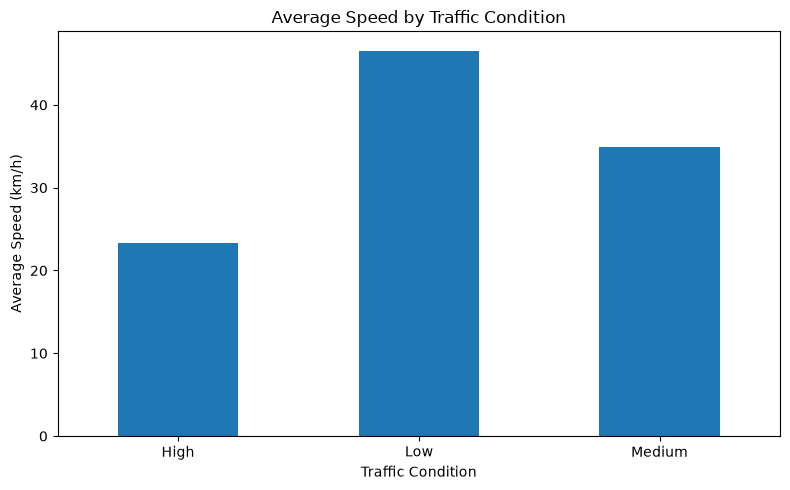

In [28]:
# Visualize average speed across traffic conditions

traffic_speed.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Average Speed by Traffic Condition")
plt.xlabel("Traffic Condition")
plt.ylabel("Average Speed (km/h)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 8.2 Weather Condition vs Average Speed

Weather conditions can influence driving conditions and consequently affect vehicle speed.

This analysis compares the average speed of trips under different weather conditions to determine whether weather is associated with changes in vehicle speed.

In [29]:
# Calculate average speed for each weather condition

weather_speed = df_eda.groupby("weather")["speed_kmh"].mean()

print("Average speed by weather condition:")
print(weather_speed)

Average speed by weather condition:
weather
Clear    38.102917
Fog      26.406637
Rain     30.755577
Name: speed_kmh, dtype: float64


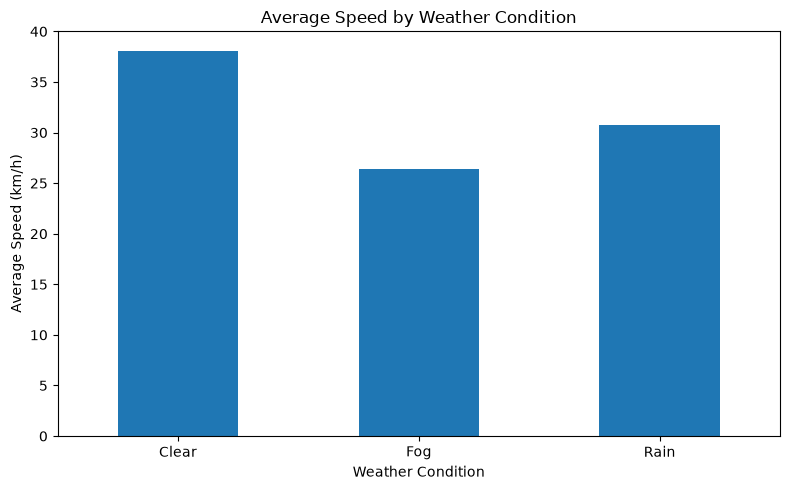

In [30]:
# Visualize average speed across weather conditions

weather_speed.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Average Speed by Weather Condition")
plt.xlabel("Weather Condition")
plt.ylabel("Average Speed (km/h)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 8.3 Vehicle Type vs Average Speed

Different vehicle types may have different speed characteristics because of their physical properties, operating conditions, and typical usage patterns.

This analysis compares the average speed of trips for different vehicle types to determine whether vehicle type is associated with variations in speed.

In [31]:
# Calculate average speed for each vehicle type

vehicle_speed = df_eda.groupby("vehicle_type")["speed_kmh"].mean()

print("Average speed by vehicle type:")
print(vehicle_speed)

Average speed by vehicle type:
vehicle_type
Bike    35.355141
Bus     35.505555
Car     35.534108
Name: speed_kmh, dtype: float64


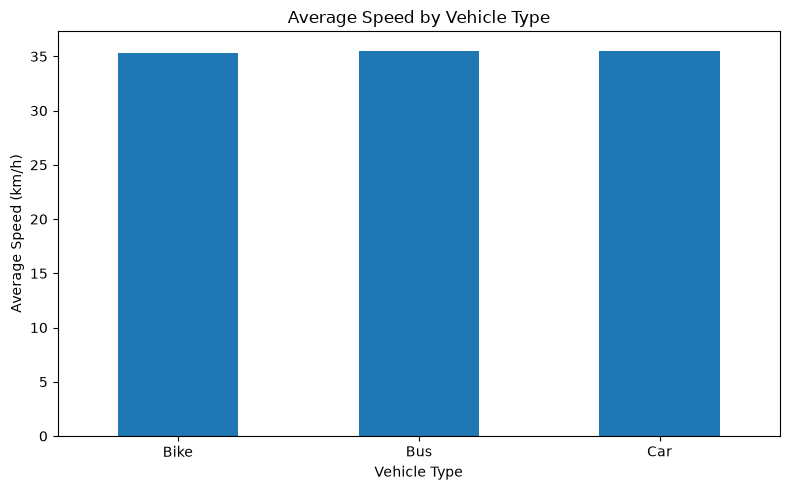

In [32]:
# Visualize average speed across vehicle types

vehicle_speed.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Average Speed by Vehicle Type")
plt.xlabel("Vehicle Type")
plt.ylabel("Average Speed (km/h)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 8.4 Distance vs Average Speed

Trip distance is an important characteristic of a journey and may be associated with differences in vehicle speed.

A scatter plot is used to examine the relationship between trip distance and average vehicle speed and to identify any visible trends or patterns in the data.

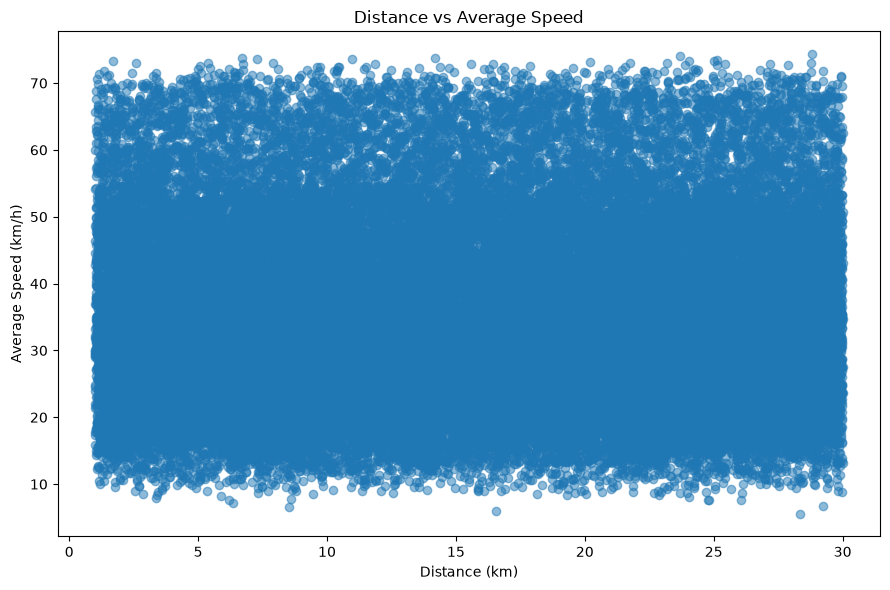

In [33]:
# Visualize the relationship between distance and average speed

plt.figure(figsize=(9, 6))

plt.scatter(
    df_eda["distance_km"],
    df_eda["speed_kmh"],
    alpha=0.5
)

plt.title("Distance vs Average Speed")
plt.xlabel("Distance (km)")
plt.ylabel("Average Speed (km/h)")
plt.tight_layout()
plt.show()

### 8.5 Traffic Condition Distribution

Understanding the distribution of traffic conditions helps determine whether the dataset contains sufficient observations across different traffic levels.

The distribution of trips across low, medium, and high traffic conditions is visualized using a bar chart.

In [34]:
# Count the number of trips under each traffic condition

traffic_counts = df_eda["traffic"].value_counts()

print("Number of trips by traffic condition:")
print(traffic_counts)

Number of trips by traffic condition:
traffic
Low       18725
High      16330
Medium    14945
Name: count, dtype: int64


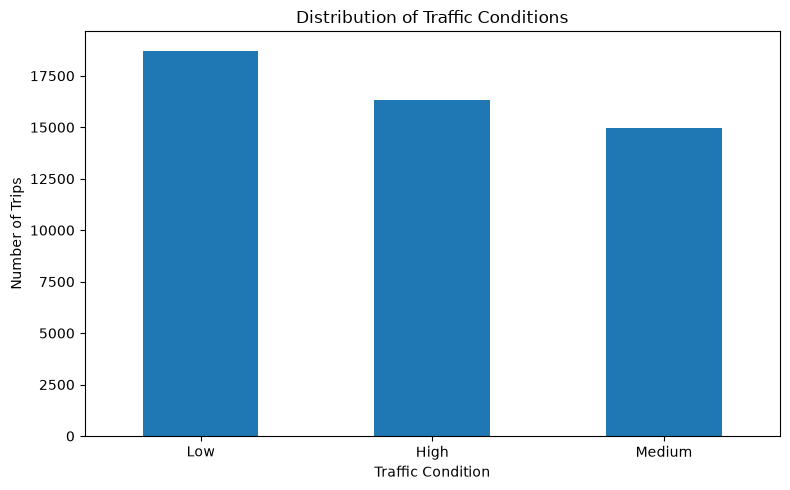

In [35]:
# Visualize the distribution of traffic conditions

traffic_counts.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Distribution of Traffic Conditions")
plt.xlabel("Traffic Condition")
plt.ylabel("Number of Trips")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Observation:** The dataset contains observations across all three traffic conditions: Low, Medium, and High. Low-traffic trips are the most frequent, followed by High-traffic and Medium-traffic trips. Although the categories are not exactly equal in size, all three traffic conditions have a substantial number of observations, providing sufficient representation for further analysis.

### 8.6 Time of Day vs Average Speed

Traffic and mobility conditions can vary throughout the day due to changes in travel demand and road usage.

This analysis examines the average vehicle speed for each hour of the day to identify time-based patterns that may be useful for predicting vehicle speed and estimating travel time.

In [36]:
# Calculate average speed for each hour of the day

hourly_speed = df_eda.groupby("hour")["speed_kmh"].mean()

print("Average speed by hour of the day:")
print(hourly_speed)

Average speed by hour of the day:
hour
0     38.526604
1     38.659378
2     38.370636
3     38.356603
4     38.455426
5     37.918253
6     38.450259
7     37.929674
8     26.431661
9     26.607020
10    27.108084
11    38.342041
12    38.664483
13    37.643854
14    38.393086
15    38.776713
16    38.845011
17    26.815992
18    26.835592
19    26.624391
20    38.275662
21    38.677433
22    38.369289
23    38.535854
Name: speed_kmh, dtype: float64


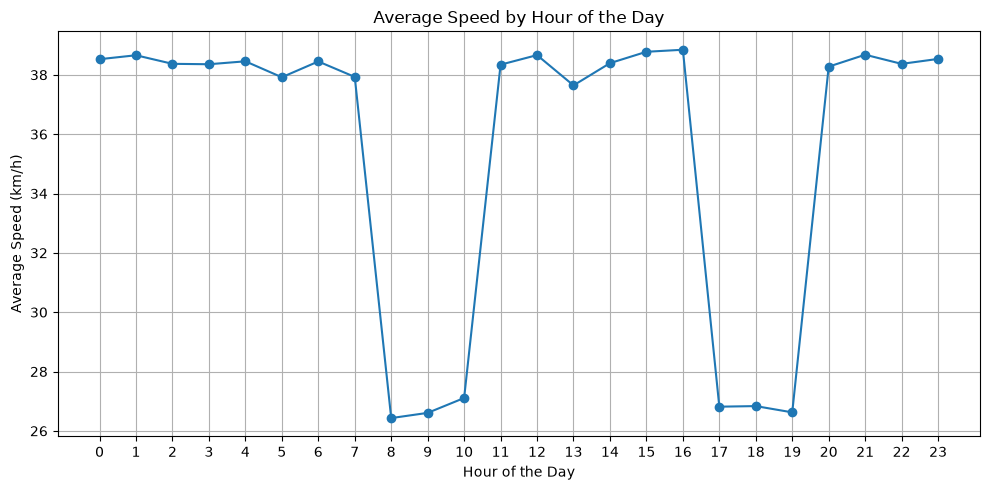

In [37]:
# Visualize average speed throughout the day

plt.figure(figsize=(10, 5))

plt.plot(
    hourly_speed.index,
    hourly_speed.values,
    marker="o"
)

plt.title("Average Speed by Hour of the Day")
plt.xlabel("Hour of the Day")
plt.ylabel("Average Speed (km/h)")
plt.xticks(range(24))
plt.grid(True)
plt.tight_layout()
plt.show()

### 8.7 Weekday vs Weekend Average Speed

Travel patterns may differ between weekdays and weekends because of differences in commuting and travel demand.

This analysis compares the average vehicle speed between weekday and weekend trips to determine whether there is a difference in mobility patterns.

In [38]:
# Calculate average speed for weekdays and weekends

weekend_speed = df_eda.groupby("is_weekend")["speed_kmh"].mean()

# Replace numeric labels with readable names
weekend_speed.index = weekend_speed.index.map({
    0: "Weekday",
    1: "Weekend"
})

print("Average speed by day type:")
print(weekend_speed)

Average speed by day type:
is_weekend
Weekday    35.427306
Weekend    35.567179
Name: speed_kmh, dtype: float64


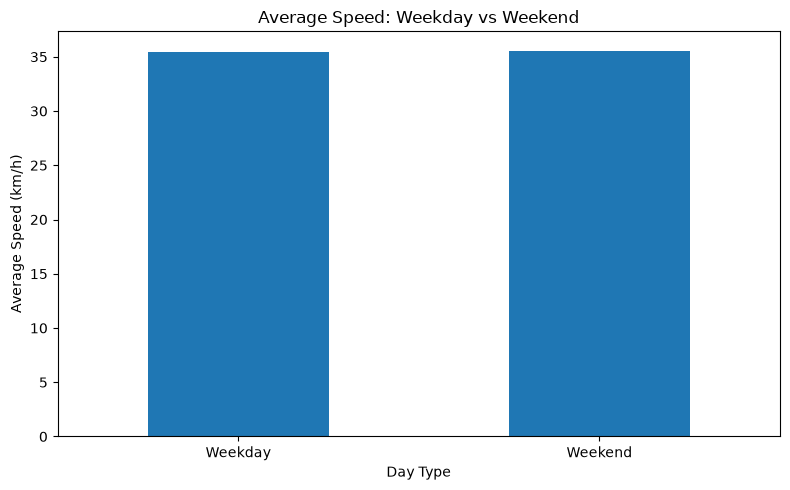

In [39]:
# Visualize average speed for weekdays and weekends

weekend_speed.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Average Speed: Weekday vs Weekend")
plt.xlabel("Day Type")
plt.ylabel("Average Speed (km/h)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Observation:** The average vehicle speed on weekdays and weekends is nearly identical, with only a very small difference between the two groups. This suggests that the `is_weekend` feature has limited influence on average speed in this dataset when considered on its own. However, it can still be retained for further analysis and evaluated along with other features during machine learning.

### 8.8 Geographic Distribution of Trips

The dataset contains geographical coordinates for the starting and ending locations of each trip.

Visualizing these coordinates helps us understand the geographical distribution of trips and demonstrates the importance of location-related features for the proposed traffic route optimization system.

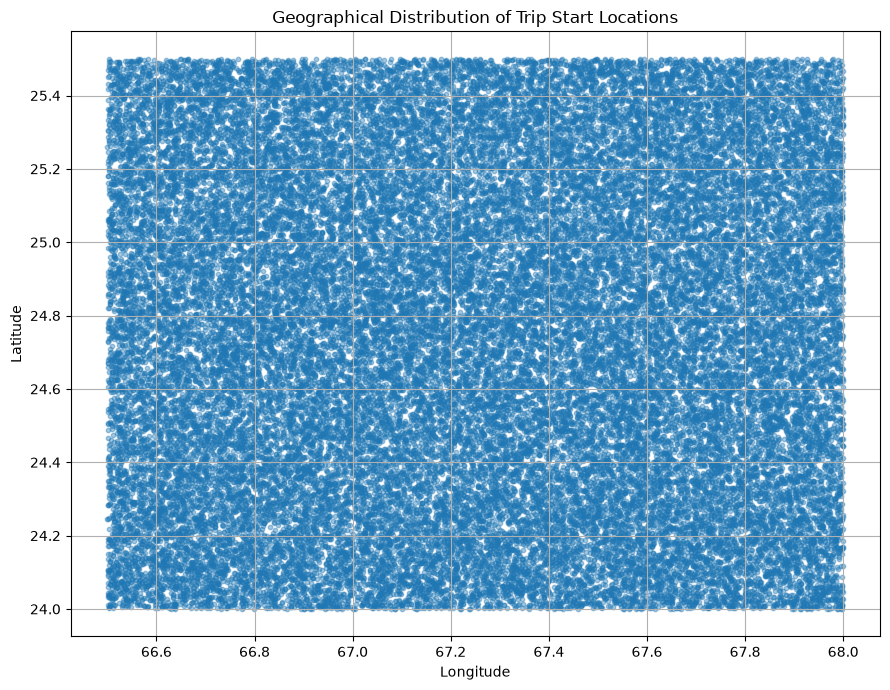

In [41]:
# Visualize the geographical distribution of trip start locations

plt.figure(figsize=(9, 7))

plt.scatter(
    df_eda["start_lon"],
    df_eda["start_lat"],
    alpha=0.4,
    s=10
)

plt.title("Geographical Distribution of Trip Start Locations")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True)
plt.tight_layout()
plt.show()

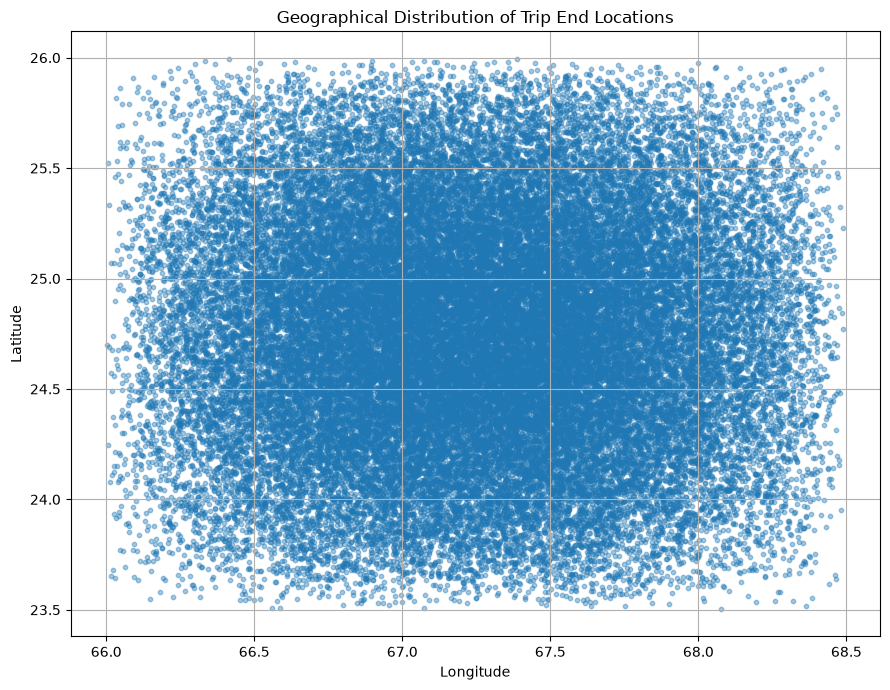

In [42]:
# Visualize the geographical distribution of trip end locations

plt.figure(figsize=(9, 7))

plt.scatter(
    df_eda["end_lon"],
    df_eda["end_lat"],
    alpha=0.4,
    s=10
)

plt.title("Geographical Distribution of Trip End Locations")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True)
plt.tight_layout()
plt.show()

**Observation:** The geographic visualizations show that trip start and end locations are distributed across a broad geographic area. The start locations appear relatively spread out across the observed latitude and longitude ranges, while the end locations show a denser concentration toward the central part of the observed region. The availability of both start and end coordinates makes geographical information an important feature for understanding trip patterns and supporting the future route optimization component of the project.

## 9. Feature Engineering

Feature engineering involves creating new meaningful features from existing data to improve the representation of the problem for machine learning.

For this project, temporal and geographical information will be transformed into additional features that can help describe traffic and mobility patterns more effectively.

The original raw dataset will remain unchanged while a separate feature-engineered dataframe is created.

### 9.1 Time-Based Feature Engineering

The timestamp feature contains information about when each trip occurred. The timestamp is converted into a datetime format and transformed into useful time-based features.

The hour and month are extracted from the timestamp, and an additional binary feature, `is_peak_hour`, is created to indicate whether a trip occurred during predefined peak commuting hours.

These features provide the machine learning model with more useful representations of temporal traffic patterns.

In [43]:
# Create a separate dataframe for feature engineering

df_features = df.copy()

# Convert timestamp to datetime format
df_features["timestamp"] = pd.to_datetime(df_features["timestamp"])

# Extract useful time-based features
df_features["hour"] = df_features["timestamp"].dt.hour
df_features["month"] = df_features["timestamp"].dt.month

# Create a peak-hour indicator
df_features["is_peak_hour"] = df_features["hour"].isin([
    7, 8, 9, 17, 18, 19
]).astype(int)

print("Feature engineering dataframe created successfully.")

print("\nNew features:")
print("hour")
print("month")
print("is_peak_hour")

df_features[[
    "timestamp",
    "hour",
    "month",
    "is_peak_hour"
]].head()

Feature engineering dataframe created successfully.

New features:
hour
month
is_peak_hour


,timestamp,hour,month,is_peak_hour
0,2025-01-24 12:20:00,12,1,0
1,2025-01-19 11:56:00,11,1,0
2,2025-01-28 10:51:00,10,1,0
3,2025-01-29 08:53:00,8,1,1
4,2025-01-13 17:30:00,17,1,1


### 9.2 Geographic Feature Engineering

The dataset provides latitude and longitude coordinates for both the starting and ending locations of each trip.

A direct geographic distance is calculated between the start and end coordinates using the Haversine formula. This provides an additional geographical feature that can be compared with the recorded trip distance and may help represent the spatial characteristics of a trip.

In [44]:
# Calculate the direct geographic distance between start and end coordinates

import numpy as np

# Convert latitude and longitude from degrees to radians
start_lat = np.radians(df_features["start_lat"])
start_lon = np.radians(df_features["start_lon"])
end_lat = np.radians(df_features["end_lat"])
end_lon = np.radians(df_features["end_lon"])

# Differences between coordinates
delta_lat = end_lat - start_lat
delta_lon = end_lon - start_lon

# Haversine formula
a = (
    np.sin(delta_lat / 2) ** 2
    + np.cos(start_lat)
    * np.cos(end_lat)
    * np.sin(delta_lon / 2) ** 2
)

c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

# Earth's approximate radius in kilometres
earth_radius_km = 6371

# Calculate direct geographic distance
df_features["direct_distance_km"] = earth_radius_km * c

print("Direct geographic distance calculated successfully.")

df_features[[
    "distance_km",
    "direct_distance_km"
]].head()

Direct geographic distance calculated successfully.


,distance_km,direct_distance_km
0,28.97,34.371669
1,8.18,48.744073
2,13.45,39.943993
3,21.47,49.418103
4,15.73,53.839844


### 9.3 Feature Engineering Verification

The newly created features are inspected to verify that the feature engineering process was completed successfully.

The engineered features include time-based variables such as `hour`, `month`, and `is_peak_hour`, along with the calculated `direct_distance_km`.

The resulting values are reviewed before proceeding to feature selection.

In [45]:
# Display the newly engineered features

engineered_features = [
    "hour",
    "month",
    "is_peak_hour",
    "direct_distance_km"
]

print("Engineered features:")
for feature in engineered_features:
    print("-", feature)

print("\nSample of engineered data:")
display(df_features[
    ["timestamp", "hour", "month", "is_peak_hour",
     "distance_km", "direct_distance_km"]
].head())

Engineered features:
- hour
- month
- is_peak_hour
- direct_distance_km

Sample of engineered data:


,timestamp,hour,month,is_peak_hour,distance_km,direct_distance_km
0,2025-01-24 12:20:00,12,1,0,28.97,34.371669
1,2025-01-19 11:56:00,11,1,0,8.18,48.744073
2,2025-01-28 10:51:00,10,1,0,13.45,39.943993
3,2025-01-29 08:53:00,8,1,1,21.47,49.418103
4,2025-01-13 17:30:00,17,1,1,15.73,53.839844


In [46]:
# Display the newly engineered features

engineered_features = [
    "hour",
    "month",
    "is_peak_hour",
    "direct_distance_km"
]

print("Engineered features:")
for feature in engineered_features:
    print("-", feature)

print("\nSample of engineered data:")
display(df_features[
    ["timestamp", "hour", "month", "is_peak_hour",
     "distance_km", "direct_distance_km"]
].head())

Engineered features:
- hour
- month
- is_peak_hour
- direct_distance_km

Sample of engineered data:


,timestamp,hour,month,is_peak_hour,distance_km,direct_distance_km
0,2025-01-24 12:20:00,12,1,0,28.97,34.371669
1,2025-01-19 11:56:00,11,1,0,8.18,48.744073
2,2025-01-28 10:51:00,10,1,0,13.45,39.943993
3,2025-01-29 08:53:00,8,1,1,21.47,49.418103
4,2025-01-13 17:30:00,17,1,1,15.73,53.839844


## 10. Feature Selection

Feature selection involves identifying the variables that are most relevant for machine learning while removing unnecessary or unsuitable columns.

For the Traffic Route Optimization System, the selected features should represent factors that can influence vehicle speed and travel conditions.

Identifier columns that do not provide meaningful predictive information will be excluded, while relevant geographical, traffic, weather, vehicle, and time-related features will be considered for the machine learning dataset.

### 10.1 Identify Identifier Columns

The dataset contains `user_id` and `trip_id`, which are identifiers used to uniquely distinguish users and trips.

These columns do not represent traffic, geographical, temporal, or vehicle characteristics and therefore are not useful predictive features for the machine learning model.

They will be excluded from the feature set while the original dataset remains unchanged.

In [47]:
# Identify identifier columns that should not be used as ML features

identifier_columns = [
    "user_id",
    "trip_id"
]

print("Identifier columns:")
for column in identifier_columns:
    print("-", column)

print("\nThese columns will be excluded from the machine learning feature set.")

Identifier columns:
- user_id
- trip_id

These columns will be excluded from the machine learning feature set.


### 10.2 Define the Target Variable

The target variable represents the value that the machine learning model will eventually learn to predict.

For the proposed Traffic Route Optimization System, `speed_kmh` is selected as the target variable.

Predicting vehicle speed allows the future system to estimate travel time using trip distance and predicted speed. The estimated travel time can subsequently be used as a cost for the route optimization component.

In [48]:
# Define the target variable for future machine learning

target_column = "speed_kmh"

print("Selected target variable:", target_column)

print("\nTarget variable description:")
print("speed_kmh represents the average vehicle speed for a trip in kilometres per hour.")

Selected target variable: speed_kmh

Target variable description:
speed_kmh represents the average vehicle speed for a trip in kilometres per hour.


### 10.3 Select Relevant Predictor Features

The candidate numerical features are examined to understand their relationship with the target variable, `speed_kmh`.

Correlation analysis is used as an initial feature-selection aid for numerical variables. This helps identify potentially useful relationships while avoiding unnecessary or redundant features.

Correlation alone is not used as the final decision criterion because some categorical and geographical features may still provide useful predictive information.

In [49]:
# Examine correlations between numerical features and the target variable

numerical_features = [
    "start_lat",
    "start_lon",
    "end_lat",
    "end_lon",
    "distance_km",
    "hour",
    "month",
    "day_of_week",
    "is_weekend",
    "is_peak_hour",
    "direct_distance_km",
    "speed_kmh"
]

correlation_matrix = df_features[numerical_features].corr()

speed_correlations = (
    correlation_matrix["speed_kmh"]
    .drop("speed_kmh")
    .sort_values(ascending=False)
)

print("Correlation of numerical features with speed_kmh:")
print(speed_correlations)

Correlation of numerical features with speed_kmh:
start_lat             0.005332
is_weekend            0.004502
direct_distance_km    0.003893
end_lat               0.003288
distance_km           0.001955
day_of_week           0.000936
start_lon            -0.000942
end_lon              -0.001206
hour                 -0.057204
is_peak_hour         -0.289476
month                      NaN
Name: speed_kmh, dtype: float64


### 10.3.2 Numerical Feature Correlation Analysis

A correlation heatmap is used to visualize the relationships among numerical features and the target variable.

This visualization helps identify potentially useful features as well as highly correlated features that may contain overlapping information.

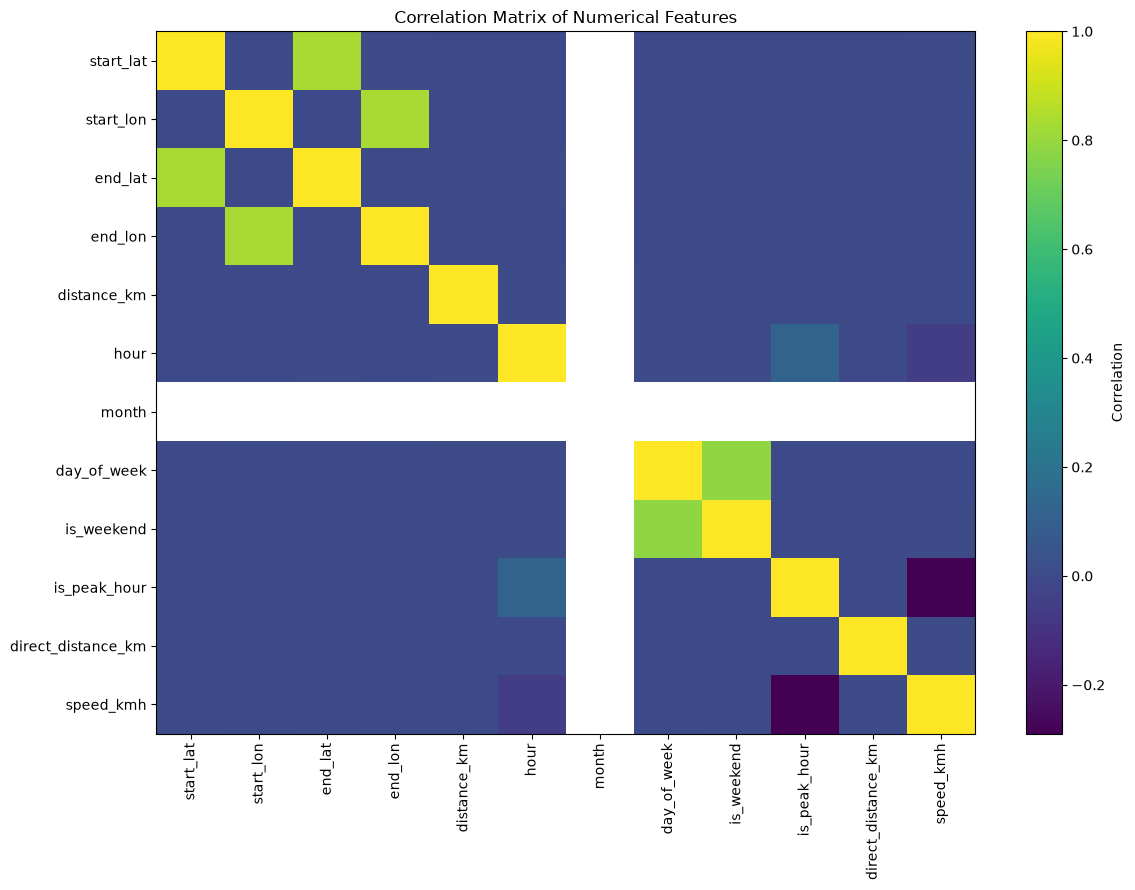

In [50]:
# Visualize the correlation matrix of numerical features

plt.figure(figsize=(12, 9))

plt.imshow(
    correlation_matrix,
    aspect="auto"
)

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title("Correlation Matrix of Numerical Features")
plt.tight_layout()
plt.show()

### 10.3.3 Numerical Feature Correlation Results

The exact correlation values between the numerical predictor variables and `speed_kmh` are examined to support the feature-selection process.

Correlation values are used as an initial indication of linear relationships. Features are not removed solely on the basis of low correlation because machine learning models can capture non-linear relationships.

In [51]:
# Display the exact correlation values with the target variable

print("Correlation of numerical features with speed_kmh:")
print()

for feature, correlation in speed_correlations.items():
    print(f"{feature:20s} : {correlation:.4f}")

Correlation of numerical features with speed_kmh:

start_lat            : 0.0053
is_weekend           : 0.0045
direct_distance_km   : 0.0039
end_lat              : 0.0033
distance_km          : 0.0020
day_of_week          : 0.0009
start_lon            : -0.0009
end_lon              : -0.0012
hour                 : -0.0572
is_peak_hour         : -0.2895
month                : nan


### 10.4 Verify Selected Features

Before creating the final feature dataset, the candidate predictor variables are checked for data availability and variation.

Features with no meaningful variation or features that duplicate information already represented by another variable may be excluded.

The verification ensures that the final feature set contains relevant information for subsequent machine learning development.

In [52]:
# Define candidate predictor features

candidate_features = [
    "start_lat",
    "start_lon",
    "end_lat",
    "end_lon",
    "distance_km",
    "traffic",
    "weather",
    "vehicle_type",
    "hour",
    "month",
    "day_of_week",
    "is_weekend",
    "is_peak_hour",
    "direct_distance_km"
]

# Create a summary of each candidate feature

feature_summary = pd.DataFrame({
    "Feature": candidate_features,
    "Data Type": [df_features[feature].dtype for feature in candidate_features],
    "Unique Values": [df_features[feature].nunique() for feature in candidate_features],
    "Missing Values": [df_features[feature].isnull().sum() for feature in candidate_features]
})

print("Candidate Feature Summary:")
display(feature_summary)

Candidate Feature Summary:


,Feature,Data Type,Unique Values,Missing Values
0,start_lat,float64,14442,0
1,start_lon,float64,14490,0
2,end_lat,float64,19103,0
3,end_lon,float64,19064,0
4,distance_km,float64,2901,0
5,traffic,str,3,0
6,weather,str,3,0
7,vehicle_type,str,3,0
8,hour,int32,24,0
9,month,int32,1,0


### 10.4.1 Check Distance Feature Redundancy

Both `distance_km` and `direct_distance_km` represent distance-related characteristics of a trip.

Their correlation is examined to determine whether they provide sufficiently different information. If the two features are highly correlated, retaining both may provide limited additional information to the machine learning model.

In [53]:
# Check the relationship between the two distance features

distance_correlation = df_features[
    ["distance_km", "direct_distance_km"]
].corr()

print("Correlation between distance features:")
display(distance_correlation)

print(
    f"\nCorrelation between distance_km and direct_distance_km: "
    f"{distance_correlation.loc['distance_km', 'direct_distance_km']:.4f}"
)

Correlation between distance features:


,distance_km,direct_distance_km
distance_km,1.000000,0.004022
direct_distance_km,0.004022,1.000000



Correlation between distance_km and direct_distance_km: 0.0040


## 10.5 Final Feature Selection

Based on the exploratory analysis, feature variation, correlation analysis, and redundancy checks, the final predictor variables are selected for subsequent machine learning development.

The identifier columns `user_id` and `trip_id` are excluded because they uniquely identify records but do not provide meaningful predictive information.

The `month` feature is excluded because the dataset contains only one month of observations and therefore the feature has no variation.

Both `distance_km` and `direct_distance_km` are retained because their correlation is very low, indicating that they provide different distance-related information.

The selected predictor variables include geographical, distance, traffic, weather, vehicle, and time-related information. The target variable is `speed_kmh`.

In [55]:
# Define the final predictor features

selected_features = [
    "start_lat",
    "start_lon",
    "end_lat",
    "end_lon",
    "distance_km",
    "direct_distance_km",
    "traffic",
    "weather",
    "vehicle_type",
    "hour",
    "day_of_week",
    "is_weekend",
    "is_peak_hour"
]

# Define the target variable

target_column = "speed_kmh"

# Create predictor dataset and target dataset

X = df_features[selected_features].copy()
y = df_features[target_column].copy()

print("Final feature selection completed successfully.")

print("\nSelected predictor features:")
for feature in selected_features:
    print("-", feature)

print("\nTarget variable:")
print("-", target_column)

print("\nShape of predictor dataset (X):", X.shape)
print("Shape of target dataset (y):", y.shape)

Final feature selection completed successfully.

Selected predictor features:
- start_lat
- start_lon
- end_lat
- end_lon
- distance_km
- direct_distance_km
- traffic
- weather
- vehicle_type
- hour
- day_of_week
- is_weekend
- is_peak_hour

Target variable:
- speed_kmh

Shape of predictor dataset (X): (50000, 13)
Shape of target dataset (y): (50000,)


### 10.5.2 Verify Predictor and Target Datasets

The predictor dataset `X` and target dataset `y` are displayed separately to verify that the selected features have been correctly assigned and that the target variable is not included among the predictors.

In [56]:
# Display the first five rows of the predictor dataset

print("First five rows of X (predictor variables):")
display(X.head())

# Display the first five values of the target variable

print("\nFirst five values of y (target variable):")
display(y.head())

# Verify that the target variable is not present in X

print("\nTarget variable present in X:", target_column in X.columns)

First five rows of X (predictor variables):


,start_lat,start_lon,end_lat,end_lon,distance_km,direct_distance_km,traffic,weather,vehicle_type,hour,day_of_week,is_weekend,is_peak_hour
0,24.6970,67.4195,24.5436,67.7147,28.97,34.371669,Low,Clear,Bus,12,4,0,0
1,24.7596,67.0422,24.3896,67.3007,8.18,48.744073,Medium,Clear,Bus,11,6,1,0
2,24.1323,67.0737,23.7858,66.9700,13.45,39.943993,High,Clear,Bus,10,1,0,0
3,24.2530,67.8358,24.6431,68.0697,21.47,49.418103,High,Clear,Car,8,2,0,1
4,24.1442,66.7141,24.4542,66.3060,15.73,53.839844,High,Fog,Bike,17,0,0,1



First five values of y (target variable):


0    31.498106
1    49.894966
2    34.706390
3    26.375888
4    22.592173
Name: speed_kmh, dtype: float64


Target variable present in X: False


## 11. Final ML-Ready Dataset

The final dataset is prepared by combining the selected predictor variables with the target variable.

The selected categorical variables are converted into numerical form using one-hot encoding so that they can be used by machine learning algorithms.

Identifier columns and features that do not provide useful predictive information are excluded. The resulting dataset represents the cleaned, transformed, and analysed data ready for subsequent machine learning model development.

### 11.1 Prepare Final Predictor Features

The selected numerical and categorical predictor variables are separated before the final encoding step.

The numerical variables are retained in their existing form, while categorical variables such as traffic condition, weather, and vehicle type will be converted into numerical indicator columns.

In [57]:
# Define the numerical and categorical features for the final ML dataset

numerical_features_final = [
    "start_lat",
    "start_lon",
    "end_lat",
    "end_lon",
    "distance_km",
    "direct_distance_km",
    "hour",
    "day_of_week",
    "is_weekend",
    "is_peak_hour"
]

categorical_features_final = [
    "traffic",
    "weather",
    "vehicle_type"
]

# Create a copy of the selected numerical features

X_numerical = X[numerical_features_final].copy()

# Create a copy of the selected categorical features

X_categorical = X[categorical_features_final].copy()

print("Numerical features prepared:")
print(numerical_features_final)

print("\nCategorical features prepared:")
print(categorical_features_final)

Numerical features prepared:
['start_lat', 'start_lon', 'end_lat', 'end_lon', 'distance_km', 'direct_distance_km', 'hour', 'day_of_week', 'is_weekend', 'is_peak_hour']

Categorical features prepared:
['traffic', 'weather', 'vehicle_type']


### 11.2 Encode Final Categorical Features

The categorical predictor variables are transformed using one-hot encoding.

One-hot encoding creates a separate numerical column for each category. This allows machine learning algorithms to use categorical information without assigning an artificial numerical order to the categories.

In [58]:
# Apply one-hot encoding to the categorical predictor variables

X_categorical_encoded = pd.get_dummies(
    X_categorical,
    columns=categorical_features_final,
    dtype=int
)

print("Categorical encoding completed successfully.")

print("\nEncoded categorical columns:")
for column in X_categorical_encoded.columns:
    print("-", column)

print("\nShape of encoded categorical data:", X_categorical_encoded.shape)

Categorical encoding completed successfully.

Encoded categorical columns:
- traffic_High
- traffic_Low
- traffic_Medium
- weather_Clear
- weather_Fog
- weather_Rain
- vehicle_type_Bike
- vehicle_type_Bus
- vehicle_type_Car

Shape of encoded categorical data: (50000, 9)


### 11.3 Combine Numerical and Encoded Features

The numerical features and one-hot encoded categorical features are combined to create the final predictor dataset.

The target variable `speed_kmh` is then appended separately to create the final machine learning dataset.

In [59]:
# Combine numerical and encoded categorical features

X_final = pd.concat(
    [X_numerical, X_categorical_encoded],
    axis=1
)

# Add the target variable

final_ml_dataset = X_final.copy()
final_ml_dataset["speed_kmh"] = y.values

print("Final ML-ready dataset created successfully.")

print("\nFinal dataset shape:", final_ml_dataset.shape)

print("\nFinal dataset columns:")
for column in final_ml_dataset.columns:
    print("-", column)

Final ML-ready dataset created successfully.

Final dataset shape: (50000, 20)

Final dataset columns:
- start_lat
- start_lon
- end_lat
- end_lon
- distance_km
- direct_distance_km
- hour
- day_of_week
- is_weekend
- is_peak_hour
- traffic_High
- traffic_Low
- traffic_Medium
- weather_Clear
- weather_Fog
- weather_Rain
- vehicle_type_Bike
- vehicle_type_Bus
- vehicle_type_Car
- speed_kmh


### 11.4 Verify the Final ML-Ready Dataset

The final dataset is inspected to verify its dimensions, data types, missing values, and first few records.

This verification confirms that the dataset contains numerical model-ready features and the selected target variable without unnecessary identifier columns.

In [60]:
# Verify the final ML-ready dataset

print("Final dataset shape:")
print(final_ml_dataset.shape)

print("\nFinal dataset data types:")
print(final_ml_dataset.dtypes)

print("\nTotal missing values:")
print(final_ml_dataset.isnull().sum().sum())

print("\nFirst five rows of the final ML-ready dataset:")
display(final_ml_dataset.head())

Final dataset shape:
(50000, 20)

Final dataset data types:
start_lat             float64
start_lon             float64
end_lat               float64
end_lon               float64
distance_km           float64
direct_distance_km    float64
hour                    int32
day_of_week             int64
is_weekend              int64
is_peak_hour            int64
traffic_High            int64
traffic_Low             int64
traffic_Medium          int64
weather_Clear           int64
weather_Fog             int64
weather_Rain            int64
vehicle_type_Bike       int64
vehicle_type_Bus        int64
vehicle_type_Car        int64
speed_kmh             float64
dtype: object

Total missing values:
0

First five rows of the final ML-ready dataset:


,start_lat,start_lon,end_lat,end_lon,distance_km,direct_distance_km,hour,day_of_week,is_weekend,is_peak_hour,traffic_High,traffic_Low,traffic_Medium,weather_Clear,weather_Fog,weather_Rain,vehicle_type_Bike,vehicle_type_Bus,vehicle_type_Car,speed_kmh
0,24.6970,67.4195,24.5436,67.7147,28.97,34.371669,12,4,0,0,0,1,0,1,0,0,0,1,0,31.498106
1,24.7596,67.0422,24.3896,67.3007,8.18,48.744073,11,6,1,0,0,0,1,1,0,0,0,1,0,49.894966
2,24.1323,67.0737,23.7858,66.9700,13.45,39.943993,10,1,0,0,1,0,0,1,0,0,0,1,0,34.706390
3,24.2530,67.8358,24.6431,68.0697,21.47,49.418103,8,2,0,1,1,0,0,1,0,0,0,0,1,26.375888
4,24.1442,66.7141,24.4542,66.3060,15.73,53.839844,17,0,0,1,1,0,0,0,1,0,1,0,0,22.592173


### 11.5 Save the Final ML-Ready Dataset

The final cleaned and transformed dataset is saved separately in the `data/processed/` directory.

The original raw dataset remains unchanged, while the processed dataset can be used as the input for subsequent machine learning model development.

In [62]:
# Save the final ML-ready dataset

processed_file_path = "../data/processed/traffic_route_ml_ready.csv"

final_ml_dataset.to_csv(
    processed_file_path,
    index=False
)

print("Final ML-ready dataset saved successfully.")
print("File location:", processed_file_path)

Final ML-ready dataset saved successfully.
File location: ../data/processed/traffic_route_ml_ready.csv
